In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [2]:
df_vendas = pd.read_parquet("../processed/df_Vendas.parquet")

In [3]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Id Loja             1145961 non-null  int64         
 2   Id Produto          1145961 non-null  int64         
 3   Id Cliente          1145961 non-null  int64         
 4   Qtd. Vendida        1145961 non-null  int64         
 5   Qtd. Devolvida      1145961 non-null  int64         
 6   Preço Unitário      1145961 non-null  float64       
 7   Nome Completo       1145961 non-null  str           
 8   Gênero              1145961 non-null  str           
 9   Data de Nascimento  1145961 non-null  datetime64[us]
 10  Nome Cliente        1145961 non-null  str           
 11  Localidade          1145961 non-null  str           
 12  Cidade              1145961 non-null  str           
 13  Tipo Loja           114

In [4]:
df_vendas["Id Cliente"].nunique()

18484

In [5]:
df_vendas["Id Produto"].nunique()

591

In [6]:
df_vendas["Id Loja"].nunique()

517

In [7]:
df_vendas["Data Venda"].min()

Timestamp('2022-01-01 00:00:00')

In [8]:
df_vendas["Data Venda"].max()

Timestamp('2024-12-30 00:00:00')

In [9]:
df_vendas = df_vendas.drop(columns={
    "Id Cliente",
    "Id Loja",
    "Id Produto"}
)

In [10]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Qtd. Vendida        1145961 non-null  int64         
 2   Qtd. Devolvida      1145961 non-null  int64         
 3   Preço Unitário      1145961 non-null  float64       
 4   Nome Completo       1145961 non-null  str           
 5   Gênero              1145961 non-null  str           
 6   Data de Nascimento  1145961 non-null  datetime64[us]
 7   Nome Cliente        1145961 non-null  str           
 8   Localidade          1145961 non-null  str           
 9   Cidade              1145961 non-null  str           
 10  Tipo Loja           1145961 non-null  str           
 11  Nome Gerente        1145961 non-null  str           
 12  Sobrenome Gerente   1145961 non-null  str           
 13  Nome Produto        114

In [11]:
df_vendas["Ano Venda"] = df_vendas["Data Venda"].dt.year
df_vendas["Mes Venda"] = df_vendas["Data Venda"].dt.month
df_vendas["Dia Semana Venda"] = df_vendas["Data Venda"].dt.day_name()

In [13]:
df_vendas["Receita"]=(
    (df_vendas["Qtd. Vendida"]-
     df_vendas["Qtd. Devolvida"])*
    df_vendas["Preço Unitário"]
)

In [14]:
df_vendas["Receita"].sum()

np.float64(555609827.55)

In [15]:
df_vendas.groupby("Ano Venda")["Receita"].sum()

Ano Venda
2022    6.584251e+07
2023    2.464511e+08
2024    2.433162e+08
Name: Receita, dtype: float64

In [ ]:
df_vendas.groupby("Ano Venda")["Receita"]

<Axes: xlabel='Ano Venda', ylabel='Receita'>

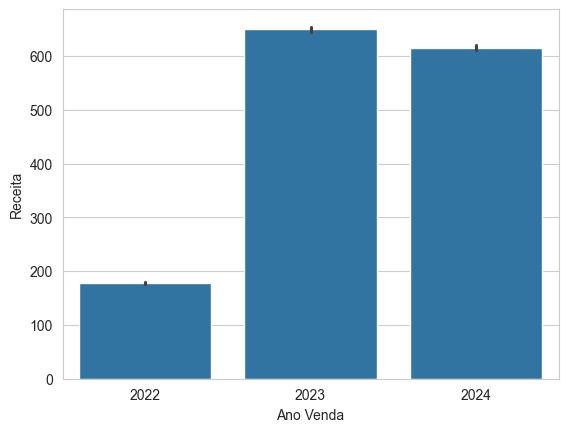

In [29]:
sns.barplot(data=df_vendas,x="Ano Venda", y="Receita")

In [32]:
df_vendas.columns

Index(['Data Venda', 'Qtd. Vendida', 'Qtd. Devolvida', 'Preço Unitário',
       'Nome Completo', 'Gênero', 'Data de Nascimento', 'Nome Cliente',
       'Localidade', 'Cidade', 'Tipo Loja', 'Nome Gerente',
       'Sobrenome Gerente', 'Nome Produto', 'Categoria', 'Marca',
       'Custo Unitário', 'Ano Venda', 'Mes Venda', 'Dia Semana Venda',
       'Receita'],
      dtype='str')

Text(0.5, 0, 'Mês')

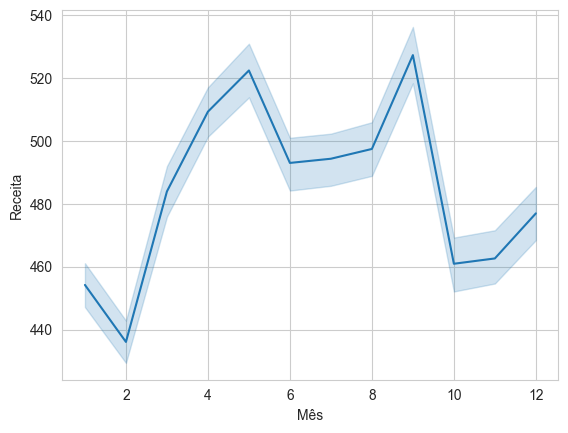

In [ ]:
sns.lineplot(data=df_vendas, x= "Mes Venda", y="Receita",)
plt.xlabel('Mês')

In [63]:
df_vendas["Qtd. Vendida"].sum()

np.int64(2117268)

In [62]:
df_vendas.groupby("Nome Produto")["Qtd. Vendida"].sum().sort_values(ascending=False).head(10)

Nome Produto
SV 16xDVD M360 Black                            240303
Camera Lens X400 Silver                          99468
Contoso USB Cable M250 White                     43163
MGS Hand Games for Office worker L299 Black      28442
SV Hand Games women M40 Black                    27191
SV Hand Games women M40 Red                      26511
MGS Hand Games women M400 Black                  25194
MGS Hand Games women M400 Yellow                 25158
MGS Hand Games for Office worker L299 Yellow     25042
MGS Hand Games women M400 Silver                 24908
Name: Qtd. Vendida, dtype: int64

In [50]:
df_vendas.groupby("Nome Produto")["Receita"].sum()

Nome Produto
A. Datum Point Shoot Digital Camera M500 Pink                  36630.00
A. Datum Super-zoom Digital Camera X300 Black                 290290.00
Adventure Works 52" LCD HDTV X590 Black                      1206395.84
Adventure Works 52" LCD HDTV X590 Brown                       307398.94
Adventure Works 52" LCD HDTV X590 Silver                     1473194.92
                                                                ...    
Wireless Transmitter and Bluetooth Headphones M150 Black      147140.19
Wireless Transmitter and Bluetooth Headphones M150 Blue       109342.71
Wireless Transmitter and Bluetooth Headphones M150 Green      103343.11
Wireless Transmitter and Bluetooth Headphones M150 Red        106942.87
Wireless Transmitter and Bluetooth Headphones M150 Silver      89844.01
Name: Receita, Length: 591, dtype: float64

---

In [52]:
df_vendas.groupby("Nome Cliente")["Receita"].sum()

Nome Cliente
2A          21700.06
Aarnildo    59764.99
Abdenego    78928.18
Abdo        58249.40
Abel        53341.17
              ...   
Ítallo      23607.47
Ítalo       45721.86
Ítele       68651.37
Úlrica      14475.94
Úrsula      48510.00
Name: Receita, Length: 7077, dtype: float64

In [60]:
df_vendas.groupby("Nome Cliente")["Receita"].mean()

Nome Cliente
2A          723.335333
Aarnildo    703.117529
Abdenego    445.921921
Abdo        571.072549
Abel        262.764384
               ...    
Ítallo      259.422747
Ítalo       831.306545
Ítele       789.096207
Úlrica      157.347174
Úrsula      238.965517
Name: Receita, Length: 7077, dtype: float64